Nama : Rangga Saputra

NIM : 250401020034

Kelas : IF405

---

# Praktikum Pertemuan 12: Asosiasi Data & Sistem Rekomendasi Dasar

## Langkah 1: Instalasi Library yang Diperlukan

Saya menemukan DeprecationWarning: datetime.datetime.utcnow(), maka saya tambahkan perbaikan DeprecationWarningnya agar tidak muncul lagi.

In [19]:
# Perbaikan agar DeprecationWarning dari jupyter_client tidak muncul lagi
import datetime as _dt
import jupyter_client.session as _session

class _PatchedDateTime(_dt.datetime):
    @classmethod
    def utcnow(cls):
        return _dt.datetime.now(_dt.timezone.utc)

_session.datetime = _PatchedDateTime

import warnings
warnings.filterwarnings('ignore')

# Install mlxtend jika belum ada
!pip install mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

# Konfigurasi display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Semua library berhasil dimuat")

Semua library berhasil dimuat


## Langkah 2: Generate & Eksplorasi Dataset Transaksi

Kita membuat dataset transaksi sintetis dengan **50 transaksi** dari **10 produk** yang memiliki pola pembelian tersembunyi. Pola utama yang disuntikkan:
- **Roti -> Selai** (roti sering dibeli bersama selai, pola yang masuk akal bisnis)
- Pola lain akan muncul secara alami dari kombinasi random

In [4]:
# Set seed untuk reproducibility
np.random.seed(42)

# Daftar 10 produk
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

print(f"Daftar Produk ({len(produk)} item):")
for i, p in enumerate(produk, 1):
    print(f"  {i:2d}. {p}")

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola bisnis: Roti sering bersama Selai (20 transaksi pertama)
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print(f"\nDibuat {len(transaksi)} transaksi")
print(f"\nContoh 5 transaksi pertama:")
for i, t in enumerate(transaksi[:5], 1):
    print(f"  Transaksi {i}: {t}")

Daftar Produk (10 item):
   1. Roti
   2. Selai
   3. Susu
   4. Sereal
   5. Telur
   6. Keju
   7. Kopi
   8. Gula
   9. Teh
  10. Mentega

Dibuat 50 transaksi

Contoh 5 transaksi pertama:
  Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
  Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
  Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
  Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
  Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]


### Eksplorasi: Frekuensi Produk Individual

Frekuensi Produk Individual:
 Produk  Frekuensi  Support
  Selai         26     0.52
    Teh         23     0.46
Mentega         21     0.42
  Telur         18     0.36
   Keju         17     0.34
   Roti         16     0.32
   Kopi         16     0.32
   Susu         16     0.32
   Gula         16     0.32
 Sereal          9     0.18


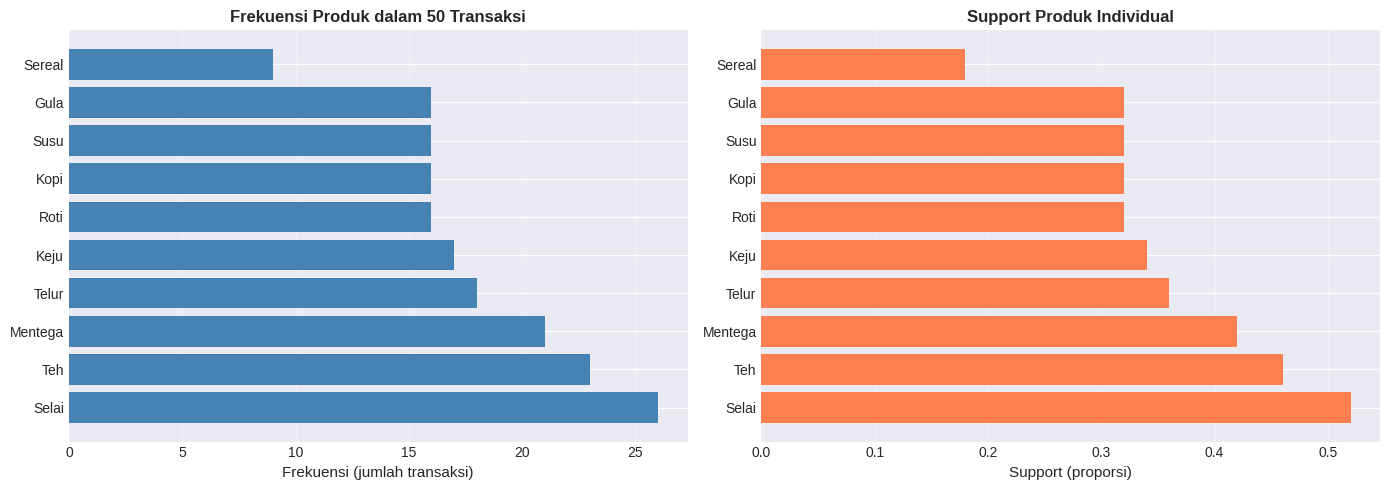


Insight: Produk paling populer adalah Selai (52.0% support)


In [5]:
# Hitung frekuensi tiap produk
produk_count = {}
for t in transaksi:
    for item in t:
        produk_count[item] = produk_count.get(item, 0) + 1

# Buat DataFrame untuk visualisasi
freq_df = pd.DataFrame([
    {'Produk': k, 'Frekuensi': v, 'Support': v / len(transaksi)}
    for k, v in sorted(produk_count.items(), key=lambda x: x[1], reverse=True)
])

print("Frekuensi Produk Individual:")
print(freq_df.to_string(index=False))

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(freq_df['Produk'], freq_df['Frekuensi'], color='steelblue')
ax1.set_xlabel('Frekuensi (jumlah transaksi)', fontsize=11)
ax1.set_title('Frekuensi Produk dalam 50 Transaksi', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(freq_df['Produk'], freq_df['Support'], color='coral')
ax2.set_xlabel('Support (proporsi)', fontsize=11)
ax2.set_title('Support Produk Individual', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInsight: Produk paling populer adalah {freq_df.iloc[0]['Produk']} "
      f"({freq_df.iloc[0]['Support']:.1%} support)")

## Langkah 3: One-Hot Encoding Transaksi

Algoritma Apriori membutuhkan data dalam format **one-hot encoding**: baris = transaksi, kolom = produk, nilai = True jika produk ada dalam transaksi, False jika tidak.

Gunakan `TransactionEncoder` dari mlxtend untuk konversi otomatis.

In [6]:
# One-hot encoding menggunakan mlxtend.TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Hasil One-Hot Encoding (10 transaksi pertama):")
print(df_encoded.head(10).astype(int))

print(f"\nShape: {df_encoded.shape[0]} transaksi x {df_encoded.shape[1]} produk")

first_row = df_encoded.iloc[0]
items_in_first = first_row[first_row == True].index.tolist()
print(f"\nInterpretasi: Transaksi 1 berisi produk: {items_in_first}")

Hasil One-Hot Encoding (10 transaksi pertama):
   Gula  Keju  Kopi  Mentega  Roti  Selai  Sereal  Susu  Teh  Telur
0     0     1     1        1     1      1       0     0    0      0
1     0     0     1        1     1      1       0     0    1      0
2     0     0     1        0     0      0       0     1    1      0
3     0     1     0        0     0      1       0     0    1      1
4     1     1     0        1     0      0       0     1    0      0
5     1     0     0        1     1      1       0     0    0      0
6     0     1     0        1     0      0       0     0    1      1
7     1     0     0        0     1      1       0     1    0      0
8     0     0     0        0     0      0       0     1    1      1
9     0     0     1        0     0      0       0     1    0      0

Shape: 50 transaksi x 10 produk

Interpretasi: Transaksi 1 berisi produk: [np.str_('Keju'), np.str_('Kopi'), np.str_('Mentega'), np.str_('Roti'), 'Selai']


## Langkah 4: Cari Frequent Itemset dengan Apriori

Jalankan algoritma Apriori dengan berbagai nilai **min_support** untuk melihat bagaimana parameter ini mempengaruhi jumlah itemset yang ditemukan.

**Penjelasan:**
- **min_support rendah (0.05)**: Akan menemukan banyak itemset, termasuk yang jarang -> bisa menghasilkan banyak noise
- **min_support sedang (0.1)**: Keseimbangan antara menemukan pola dan menghindari noise
- **min_support tinggi (0.2-0.3)**: Hanya itemset yang sangat populer yang lolos -> mungkin melewatkan pola penting

In [7]:
# Eksperimen dengan berbagai min_support
print("Pengaruh Parameter min_support pada Jumlah Itemset:")
print("=" * 60)

min_support_values = [0.05, 0.1, 0.15, 0.2, 0.3]
results = []

for ms in min_support_values:
    freq = apriori(df_encoded, min_support=ms, use_colnames=True)
    row = {
        'min_support': ms,
        'Jumlah Itemset': len(freq),
        'Itemset (k=1)': len(freq[freq['itemsets'].apply(len) == 1]),
        'Itemset (k=2)': len(freq[freq['itemsets'].apply(len) == 2]),
        'Itemset (k>=3)': len(freq[freq['itemsets'].apply(len) >= 3]),
    }
    results.append(row)
    print(f"min_support={ms}: {row['Jumlah Itemset']:3d} itemset "
          f"(1-item: {row['Itemset (k=1)']:2d}, 2-item: {row['Itemset (k=2)']:2d}, "
          f">=3-item: {row['Itemset (k>=3)']:2d})")

print("\nRekomendasi: Gunakan min_support=0.1 untuk keseimbangan jumlah itemset yang wajar")

# Gunakan min_support=0.1 untuk analisis lanjutan
freq_items = apriori(df_encoded, min_support=0.1, use_colnames=True)

# Catatan kompatibilitas: pastikan nama item berupa string Python biasa
# (bukan numpy.str_), karena versi mlxtend + numpy tertentu bisa error
# saat membentuk association_rules jika item masih bertipe numpy.
freq_items['itemsets'] = freq_items['itemsets'].apply(
    lambda s: frozenset(str(item) for item in s)
)

freq_items = freq_items.sort_values('support', ascending=False)

print(f"\nTop 15 Frequent Itemset (min_support=0.1):")
print("=" * 60)
for idx, row in freq_items.head(15).iterrows():
    itemset_str = ', '.join(sorted(row['itemsets']))
    print(f"  {{{itemset_str:<30s}}} -> support: {row['support']:.1%}")

Pengaruh Parameter min_support pada Jumlah Itemset:
min_support=0.05:  74 itemset (1-item: 10, 2-item: 40, >=3-item: 24)
min_support=0.1:  44 itemset (1-item: 10, 2-item: 30, >=3-item:  4)
min_support=0.15:  19 itemset (1-item: 10, 2-item:  9, >=3-item:  0)
min_support=0.2:  13 itemset (1-item:  9, 2-item:  4, >=3-item:  0)
min_support=0.3:   9 itemset (1-item:  9, 2-item:  0, >=3-item:  0)

Rekomendasi: Gunakan min_support=0.1 untuk keseimbangan jumlah itemset yang wajar

Top 15 Frequent Itemset (min_support=0.1):
  {Selai                         } -> support: 52.0%
  {Teh                           } -> support: 46.0%
  {Mentega                       } -> support: 42.0%
  {Telur                         } -> support: 36.0%
  {Keju                          } -> support: 34.0%
  {Gula                          } -> support: 32.0%
  {Kopi                          } -> support: 32.0%
  {Roti                          } -> support: 32.0%
  {Susu                          } -> support: 32.0%
  

### Visualisasi: Distribusi Support Itemset

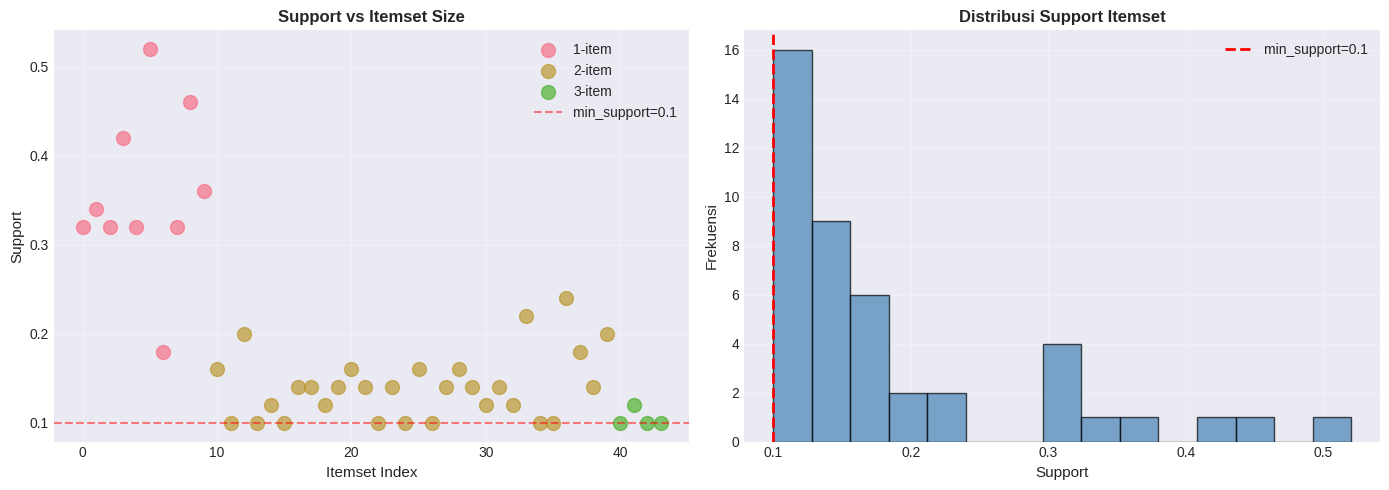

Total 44 itemset ditemukan dengan min_support=0.1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freq_items['itemset_size'] = freq_items['itemsets'].apply(len)
for size in sorted(freq_items['itemset_size'].unique()):
    subset = freq_items[freq_items['itemset_size'] == size]
    axes[0].scatter(subset.index, subset['support'],
                    label=f'{size}-item', s=100, alpha=0.7)

axes[0].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='min_support=0.1')
axes[0].set_xlabel('Itemset Index', fontsize=11)
axes[0].set_ylabel('Support', fontsize=11)
axes[0].set_title('Support vs Itemset Size', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(freq_items['support'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='min_support=0.1')
axes[1].set_xlabel('Support', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].set_title('Distribusi Support Itemset', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total {len(freq_items)} itemset ditemukan dengan min_support=0.1")

## Langkah 5: Bentuk & Saring Aturan Asosiasi

Dari **frequent itemset**, kita bentuk **association rules** (aturan asosiasi) dalam format `A -> B` (jika membeli A, maka beli B).

Kemudian saring dengan **min_confidence** dan **min_lift** untuk mendapatkan aturan yang bermakna:
- **Confidence >= 0.5**: Minimal 50% pembeli A juga membeli B
- **Lift > 1**: A dan B berkorelasi positif (tidak independen)

In [9]:
# Bentuk association rules dari frequent itemset
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)

print(f"Total rules sebelum filter: {len(rules)}")

# Saring dengan min_lift > 1
rules_filtered = rules[rules['lift'] > 1].copy()
rules_filtered = rules_filtered.sort_values('lift', ascending=False)

print(f"Rules setelah filter (confidence >= 0.5, lift > 1): {len(rules_filtered)}")

if len(rules_filtered) > 0:
    print(f"\nTop 10 Association Rules (sorted by Lift):")
    print("=" * 90)

    for idx, (i, row) in enumerate(rules_filtered.head(10).iterrows(), 1):
        ant = ', '.join(sorted(row['antecedents']))
        cons = ', '.join(sorted(row['consequents']))
        print(f"\n{idx}. {{{ant}}} -> {{{cons}}}")
        print(f"   Confidence: {row['confidence']:.1%} | Support: {row['support']:.1%} | Lift: {row['lift']:.2f}")

        if row['lift'] > 2:
            strength = "SANGAT KUAT"
        elif row['lift'] > 1.5:
            strength = "KUAT"
        else:
            strength = "LEMAH"
        print(f"   Kekuatan: {strength}")
else:
    print("Tidak ada rules yang memenuhi kriteria. Coba turunkan min_confidence atau min_lift")

Total rules sebelum filter: 18
Rules setelah filter (confidence >= 0.5, lift > 1): 16

Top 10 Association Rules (sorted by Lift):

1. {Keju, Teh} -> {Telur}
   Confidence: 85.7% | Support: 12.0% | Lift: 2.38
   Kekuatan: SANGAT KUAT

2. {Mentega, Selai} -> {Kopi}
   Confidence: 62.5% | Support: 10.0% | Lift: 1.95
   Kekuatan: KUAT

3. {Gula, Roti} -> {Selai}
   Confidence: 100.0% | Support: 10.0% | Lift: 1.92
   Kekuatan: KUAT

4. {Sereal} -> {Mentega}
   Confidence: 77.8% | Support: 14.0% | Lift: 1.85
   Kekuatan: KUAT

5. {Teh, Telur} -> {Keju}
   Confidence: 60.0% | Support: 12.0% | Lift: 1.76
   Kekuatan: KUAT

6. {Kopi, Selai} -> {Mentega}
   Confidence: 71.4% | Support: 10.0% | Lift: 1.70
   Kekuatan: KUAT

7. {Keju, Telur} -> {Teh}
   Confidence: 75.0% | Support: 12.0% | Lift: 1.63
   Kekuatan: KUAT

8. {Gula, Selai} -> {Roti}
   Confidence: 50.0% | Support: 10.0% | Lift: 1.56
   Kekuatan: KUAT

9. {Kopi, Mentega} -> {Selai}
   Confidence: 71.4% | Support: 10.0% | Lift: 1.37
   

### Interpretasi Hasil

**Apa arti hasil di atas?**

Misalkan rule pertama adalah: `{Roti} -> {Selai}` dengan Confidence 75% dan Lift 2.5
- **Confidence 75%**: Dari semua pembeli Roti, 75% juga membeli Selai
- **Lift 2.5**: Pembeli Roti 2.5x lebih mungkin membeli Selai dibanding pembeli acak
  - Ini berarti ada hubungan kuat antara Roti dan Selai, bukan kebetulan

**Aplikasi bisnis:**
- Letakkan Roti dan Selai berdekatan di rak supermarket
- Bundling: "Beli Roti, dapat Selai 20% lebih murah"
- Email marketing: "Pelanggan yang suka Roti, jangan lupa Selai!"

### Visualisasi: Scatter Plot Confidence vs Lift

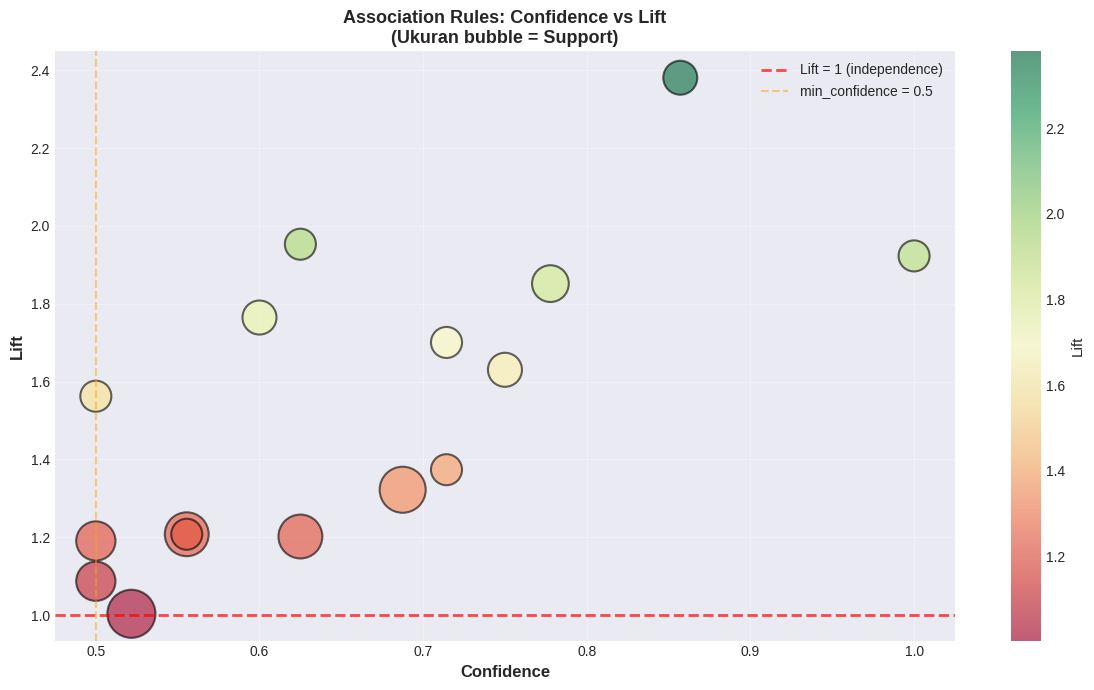

Area kanan-atas (high confidence, high lift) adalah rules paling berharga


In [10]:
if len(rules_filtered) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(
        rules_filtered['confidence'],
        rules_filtered['lift'],
        s=rules_filtered['support'] * 5000,
        alpha=0.6,
        c=rules_filtered['lift'],
        cmap='RdYlGn',
        edgecolors='black',
        linewidth=1.5
    )

    ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Lift = 1 (independence)')
    ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='min_confidence = 0.5')

    ax.set_xlabel('Confidence', fontsize=12, fontweight='bold')
    ax.set_ylabel('Lift', fontsize=12, fontweight='bold')
    ax.set_title('Association Rules: Confidence vs Lift\n(Ukuran bubble = Support)',
                 fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Lift', fontsize=11)

    plt.tight_layout()
    plt.show()

    print("Area kanan-atas (high confidence, high lift) adalah rules paling berharga")
else:
    print("Tidak ada rules untuk divisualisasikan")

## Langkah 6: Rekomender Sederhana dengan Content-Based Filtering

Content-Based Filtering merekomendasikan produk yang **mirip** dengan produk yang pengguna sukai, berdasarkan **atribut/kategori produk**.

**Pendekatan:**
1. Buat katalog produk dengan kategorinya
2. One-hot encode kategori untuk setiap produk
3. Hitung **cosine similarity** antar produk
4. Untuk produk A, rekomendasikan produk B yang paling mirip

In [11]:
# Buat katalog produk dengan kategori
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'],
    'harga_rb': [15, 25, 20, 30, 18, 35, 40, 10, 22, 32]
})

print("Katalog Produk:")
print("=" * 50)
print(katalog.to_string(index=False))

print(f"\nDistribusi Kategori:")
print(katalog['kategori'].value_counts().to_string())

Katalog Produk:
 produk kategori  harga_rb
   Roti   Bakery        15
  Selai   Bakery        25
   Susu    Dairy        20
 Sereal   Bakery        30
  Telur    Dairy        18
   Keju    Dairy        35
   Kopi  Minuman        40
   Gula    Bumbu        10
    Teh  Minuman        22
Mentega    Dairy        32

Distribusi Kategori:
kategori
Dairy      4
Bakery     3
Minuman    2
Bumbu      1


### Hitung Cosine Similarity antar Produk

In [12]:
# One-hot encode kategori
fitur_kategori = pd.get_dummies(katalog['kategori'])

print("Fitur One-Hot Kategori:")
print(fitur_kategori)

# Hitung cosine similarity
sim_matrix = cosine_similarity(fitur_kategori)
sim_df = pd.DataFrame(
    sim_matrix,
    index=katalog['produk'],
    columns=katalog['produk']
)

print("\nSimilarity Matrix (Cosine Similarity berdasarkan Kategori):")
print("=" * 70)
print(sim_df.round(2))

print("\nInterpretasi:")
print("  - 1.0: Produk dari kategori yang sama (100% mirip)")
print("  - 0.0: Produk dari kategori berbeda (tidak mirip)")

Fitur One-Hot Kategori:
   Bakery  Bumbu  Dairy  Minuman
0    True  False  False    False
1    True  False  False    False
2   False  False   True    False
3    True  False  False    False
4   False  False   True    False
5   False  False   True    False
6   False  False  False     True
7   False   True  False    False
8   False  False  False     True
9   False  False   True    False

Similarity Matrix (Cosine Similarity berdasarkan Kategori):
produk   Roti  Selai  Susu  Sereal  Telur  Keju  Kopi  Gula  Teh  Mentega
produk                                                                   
Roti      1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Selai     1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Susu      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Sereal    1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Telur     0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Keju      0.0    0.0   1.0     0.0

### Fungsi Rekomendasi Content-Based

In [13]:
def rekomendasi_content_based(nama_produk, top_n=3):
    """
    Rekomendasi produk serupa berdasarkan kategori.

    Parameter:
    - nama_produk: Nama produk yang ingin dicari produk serupa-nya
    - top_n: Jumlah rekomendasi yang ingin ditampilkan

    Return:
    - Series (produk -> similarity_score)
    """
    if nama_produk not in sim_df.index:
        return f"Produk '{nama_produk}' tidak ditemukan dalam katalog"

    similarity_scores = sim_df.loc[nama_produk].sort_values(ascending=False)
    rekomendasi = similarity_scores[1:top_n + 1]
    return rekomendasi


produk_test = 'Roti'
print(f"\nContent-Based Filtering: Produk Mirip dengan '{produk_test}'")
print("=" * 60)

rekomendasi = rekomendasi_content_based(produk_test, top_n=5)
for i, (prod, score) in enumerate(rekomendasi.items(), 1):
    kategori_prod = katalog[katalog['produk'] == prod]['kategori'].values[0]
    print(f"{i}. {prod:<15} | Kategori: {kategori_prod:<12} | Similarity: {score:.2f}")

print(f"\nInsight: Rekomendasi berdasarkan kategori yang sama")


Content-Based Filtering: Produk Mirip dengan 'Roti'
1. Selai           | Kategori: Bakery       | Similarity: 1.00
2. Sereal          | Kategori: Bakery       | Similarity: 1.00
3. Susu            | Kategori: Dairy        | Similarity: 0.00
4. Telur           | Kategori: Dairy        | Similarity: 0.00
5. Keju            | Kategori: Dairy        | Similarity: 0.00

Insight: Rekomendasi berdasarkan kategori yang sama


### Visualisasi: Content-Based Similarity Heatmap

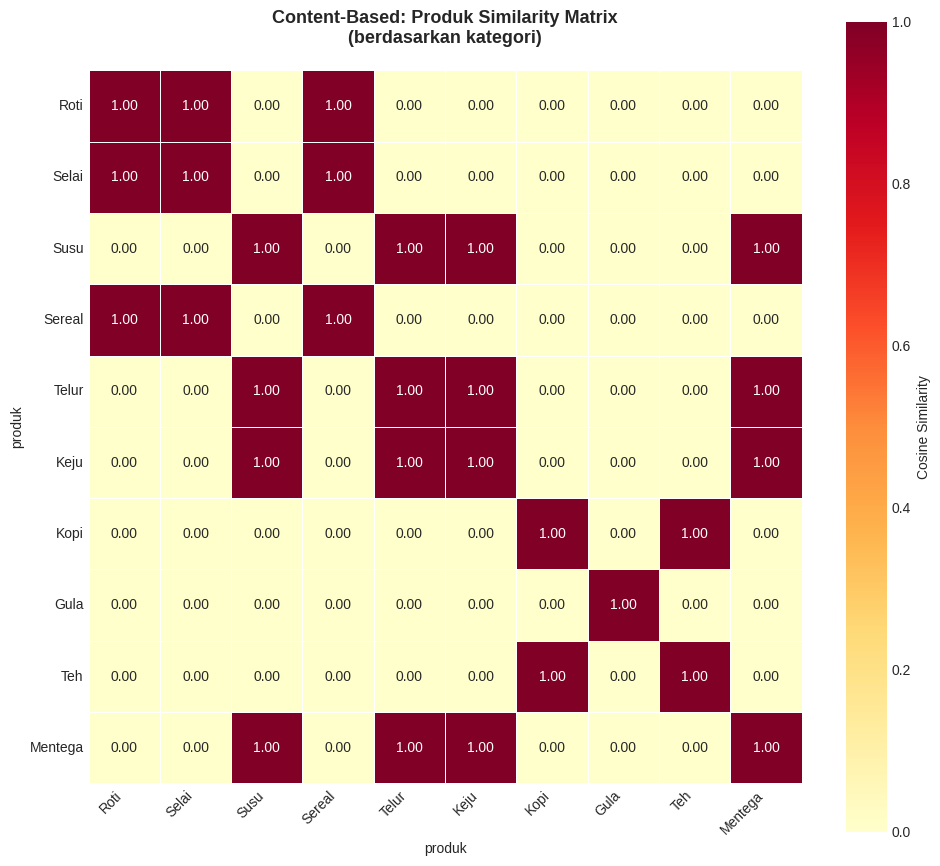

Baris/kolom dengan warna terang = produk yang mirip


In [14]:
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(
    sim_df,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Cosine Similarity'},
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Content-Based: Produk Similarity Matrix\n(berdasarkan kategori)',
             fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Baris/kolom dengan warna terang = produk yang mirip")

## Langkah 7: Bandingkan Kedua Pendekatan

Kita membandingkan rekomendasi dari dua pendekatan:
1. **Association Rules** (Market Basket): "Orang yang beli X juga beli Y"
2. **Content-Based Filtering**: "Y mirip dengan X (kategori sama)"

**Pertanyaan penting:**
- Apakah kedua pendekatan memberikan rekomendasi yang sama?
- Kapan masing-masing lebih cocok?

In [15]:
produk_target = 'Roti'

print(f"PERBANDINGAN REKOMENDASI UNTUK PRODUK: {produk_target}")
print("=" * 70)

# === Pendekatan 1: Association Rules ===
print(f"\n1) ASSOCIATION RULES (Market Basket Analysis)")
print("-" * 70)

rules_terkait = rules_filtered[
    rules_filtered['antecedents'].apply(lambda x: produk_target in x)
].sort_values('lift', ascending=False)

rekomendasi_rules = []
if len(rules_terkait) > 0:
    print(f"Ditemukan {len(rules_terkait)} rule dengan antecedent mengandung '{produk_target}':\n")
    for idx, (i, row) in enumerate(rules_terkait.iterrows(), 1):
        cons = ', '.join(sorted(row['consequents']))
        print(f"{idx}. {{{produk_target}}} -> {{{cons}}}")
        print(f"   Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}")
        rekomendasi_rules.append(list(row['consequents'])[0])
    print(f"\nRekomendasi dari Association Rules: {rekomendasi_rules[:5]}")
else:
    print(f"Tidak ada association rules untuk produk '{produk_target}'")

# === Pendekatan 2: Content-Based Filtering ===
print(f"\n\n2) CONTENT-BASED FILTERING (Similarity Kategori)")
print("-" * 70)

rekomendasi_content = rekomendasi_content_based(produk_target, top_n=5)
print(f"Produk serupa dengan '{produk_target}' (kategori sama):\n")

rekomendasi_cb_list = []
for i, (prod, score) in enumerate(rekomendasi_content.items(), 1):
    kategori = katalog[katalog['produk'] == prod]['kategori'].values[0]
    print(f"{i}. {prod:<15} (Kategori: {kategori:<12}) | Similarity: {score:.2f}")
    rekomendasi_cb_list.append(prod)

print(f"\nRekomendasi dari Content-Based: {rekomendasi_cb_list}")

PERBANDINGAN REKOMENDASI UNTUK PRODUK: Roti

1) ASSOCIATION RULES (Market Basket Analysis)
----------------------------------------------------------------------
Ditemukan 2 rule dengan antecedent mengandung 'Roti':

1. {Roti} -> {Selai}
   Confidence: 100.0% | Lift: 1.92
2. {Roti} -> {Selai}
   Confidence: 68.8% | Lift: 1.32

Rekomendasi dari Association Rules: ['Selai', 'Selai']


2) CONTENT-BASED FILTERING (Similarity Kategori)
----------------------------------------------------------------------
Produk serupa dengan 'Roti' (kategori sama):

1. Selai           (Kategori: Bakery      ) | Similarity: 1.00
2. Sereal          (Kategori: Bakery      ) | Similarity: 1.00
3. Susu            (Kategori: Dairy       ) | Similarity: 0.00
4. Telur           (Kategori: Dairy       ) | Similarity: 0.00
5. Keju            (Kategori: Dairy       ) | Similarity: 0.00

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu', 'Telur', 'Keju']


### Analisis Perbandingan Mendalam

In [16]:
print("\n\nANALISIS PERBANDINGAN")
print("=" * 80)

print(f"\nTarget Produk: {produk_target}")
print(f"   Kategori: {katalog[katalog['produk'] == produk_target]['kategori'].values[0]}")
print(f"   Harga: Rp {katalog[katalog['produk'] == produk_target]['harga_rb'].values[0]} ribu")

print(f"\nAssociation Rules (seberapa sering dibeli bersama):")
if rekomendasi_rules:
    print(f"   Menemukan {len(rekomendasi_rules)} item yang sering dibeli bersama")
    print(f"   Rekomendasi: {rekomendasi_rules[:3]}")
    print(f"   Manfaat: Lebih 'mengejutkan', bisa cross-sell yang efektif")
else:
    print(f"   Tidak ada pola pembelian bersama yang ditemukan")

print(f"\nContent-Based Filtering (seberapa mirip):")
print(f"   Menemukan {len(rekomendasi_cb_list)} item dengan kategori sama")
print(f"   Rekomendasi: {rekomendasi_cb_list[:3]}")
print(f"   Manfaat: Lebih predictable, cocok untuk cold-start")

print(f"\nKesimpulan:")
if rekomendasi_rules and rekomendasi_cb_list:
    overlap = set(rekomendasi_rules) & set(rekomendasi_cb_list)
    if overlap:
        print(f"   Kedua pendekatan setuju pada: {overlap}")
        print(f"   Ini adalah rekomendasi terbaik (paling confident)")
    else:
        print(f"   Kedua pendekatan memberikan rekomendasi berbeda")
        print(f"   Hybrid approach: gunakan keduanya untuk diversity")
else:
    print(f"   Salah satu pendekatan tidak memberikan rekomendasi")



ANALISIS PERBANDINGAN

Target Produk: Roti
   Kategori: Bakery
   Harga: Rp 15 ribu

Association Rules (seberapa sering dibeli bersama):
   Menemukan 2 item yang sering dibeli bersama
   Rekomendasi: ['Selai', 'Selai']
   Manfaat: Lebih 'mengejutkan', bisa cross-sell yang efektif

Content-Based Filtering (seberapa mirip):
   Menemukan 5 item dengan kategori sama
   Rekomendasi: ['Selai', 'Sereal', 'Susu']
   Manfaat: Lebih predictable, cocok untuk cold-start

Kesimpulan:
   Kedua pendekatan setuju pada: {'Selai'}
   Ini adalah rekomendasi terbaik (paling confident)


### Kapan Menggunakan Masing-Masing Pendekatan?

| Situasi | Association Rules | Content-Based | Hybrid |
|---------|-------------------|----------------|--------|
| **Cold Start** (produk baru) | Tidak ada transaksi | Gunakan metadata | Hybrid |
| **Cross-Selling** (bundel produk) | Sangat baik | Hanya rekomendasi produk sama | Hybrid |
| **Histori Data Melimpah** | Semakin baik | Tetap baik | Optimal |
| **Diversitas Rekomendasi** | Bisa repetitif | Lebih beragam | Hybrid |
| **Serendipity (kejutan)** | Bisa mengejutkan | Predictable | Hybrid |

## Langkah 8: Ringkasan & Sistem Hybrid

Sistem rekomendasi produksi (Netflix, Spotify, Amazon) menggabungkan kedua pendekatan menjadi **sistem hybrid** untuk mendapatkan keuntungan keduanya.

In [17]:
print("=" * 80)
print("REKOMENDASI SISTEM HYBRID")
print("=" * 80)

print(f"\nUntuk Produk: {produk_target}")
print("-" * 80)

rekomendasi_hybrid = {}

# Dari Association Rules (bobot: 60%)
for prod in rekomendasi_rules[:3]:
    rekomendasi_hybrid[prod] = rekomendasi_hybrid.get(prod, 0) + 0.60

# Dari Content-Based (bobot: 40%)
for prod in rekomendasi_cb_list[:3]:
    rekomendasi_hybrid[prod] = rekomendasi_hybrid.get(prod, 0) + 0.40

rekomendasi_hybrid_sorted = sorted(
    rekomendasi_hybrid.items(),
    key=lambda x: x[1],
    reverse=True
)

print(f"\nRekomendasi Hybrid (Association 60% + Content-Based 40%):")
print("-" * 80)

for rank, (prod, score) in enumerate(rekomendasi_hybrid_sorted, 1):
    kategori = katalog[katalog['produk'] == prod]['kategori'].values[0]
    harga = katalog[katalog['produk'] == prod]['harga_rb'].values[0]
    print(f"{rank}. {prod:<15} | Kategori: {kategori:<12} | Harga: Rp{harga}k | Score: {score:.2f}")

print(f"\nKeuntungan Sistem Hybrid:")
print(f"   - Menggabungkan pola pembelian (Association Rules) dan kesamaan produk")
print(f"   - Lebih robust terhadap cold-start")
print(f"   - Rekomendasi lebih beragam dan relevan")

REKOMENDASI SISTEM HYBRID

Untuk Produk: Roti
--------------------------------------------------------------------------------

Rekomendasi Hybrid (Association 60% + Content-Based 40%):
--------------------------------------------------------------------------------
1. Selai           | Kategori: Bakery       | Harga: Rp25k | Score: 1.60
2. Sereal          | Kategori: Bakery       | Harga: Rp30k | Score: 0.40
3. Susu            | Kategori: Dairy        | Harga: Rp20k | Score: 0.40

Keuntungan Sistem Hybrid:
   - Menggabungkan pola pembelian (Association Rules) dan kesamaan produk
   - Lebih robust terhadap cold-start
   - Rekomendasi lebih beragam dan relevan


### Metrik Evaluasi Sistem Rekomendasi

In [18]:
def precision_at_k(rekomendasi, item_relevan, k=5):
    """
    Hitung Precision@K: proporsi item relevan dalam top-K rekomendasi.

    Formula:
        Precision@K = (jumlah item relevan di top-K) / K

    Parameter:
    - rekomendasi: list produk yang direkomendasikan (sorted by score)
    - item_relevan: list produk yang benar-benar relevan/disukai user
    - k: berapa banyak top rekomendasi yang dievaluasi

    Return:
    - float: precision score [0, 1]
    """
    top_k = rekomendasi[:k]
    relevan_ditemukan = len(set(top_k) & set(item_relevan))
    return relevan_ditemukan / k if k > 0 else 0


# Simulasi: item yang "relevan" (disukai user)
# Misalkan user menyukai produk dari kategori 'Bakery' (kategori sama dengan Roti)
item_disukai_user = [
    p for p in katalog['produk']
    if katalog[katalog['produk'] == p]['kategori'].values[0] == 'Bakery'
]

print(f"EVALUASI SISTEM REKOMENDASI")
print("=" * 80)
print(f"\nAsumsi: User menyukai produk kategori 'Bakery' = {item_disukai_user}")
print("-" * 80)

rekomendasi_list = [p for p, _ in rekomendasi_hybrid_sorted]

for k in [3, 5, 10]:
    prec = precision_at_k(rekomendasi_list, item_disukai_user, k=k)
    print(f"\nPrecision@{k}: {prec:.1%}")
    top_k_items = rekomendasi_list[:k]
    relevan = [p for p in top_k_items if p in item_disukai_user]
    print(f"  Top-{k}: {top_k_items}")
    print(f"  Relevan: {relevan} ({len(relevan)}/{k})")

    if prec >= 0.7:
        print(f"  -> Sangat Baik! Sebagian besar rekomendasi relevan")
    elif prec >= 0.4:
        print(f"  -> Cukup baik, masih ada ruang perbaikan")
    else:
        print(f"  -> Kurang baik, perlu evaluasi ulang")

EVALUASI SISTEM REKOMENDASI

Asumsi: User menyukai produk kategori 'Bakery' = ['Roti', 'Selai', 'Sereal']
--------------------------------------------------------------------------------

Precision@3: 66.7%
  Top-3: ['Selai', 'Sereal', 'Susu']
  Relevan: ['Selai', 'Sereal'] (2/3)
  -> Cukup baik, masih ada ruang perbaikan

Precision@5: 40.0%
  Top-5: ['Selai', 'Sereal', 'Susu']
  Relevan: ['Selai', 'Sereal'] (2/5)
  -> Cukup baik, masih ada ruang perbaikan

Precision@10: 20.0%
  Top-10: ['Selai', 'Sereal', 'Susu']
  Relevan: ['Selai', 'Sereal'] (2/10)
  -> Kurang baik, perlu evaluasi ulang


## Kesimpulan & Ringkasan

### Yang Telah Dipelajari

**Association Rule Mining (Apriori)**
- Konsep itemset, support, confidence, lift
- Algoritma Apriori dan prinsip downward closure
- Implementasi dengan mlxtend
- Aplikasi: Market Basket Analysis, cross-selling

**Sistem Rekomendasi Dasar**
- **Collaborative Filtering**: berdasarkan pola perilaku pengguna lain
- **Content-Based Filtering**: berdasarkan kesamaan atribut produk
- Perbandingan keduanya dan kapan digunakan

**Evaluasi Sistem Rekomendasi**
- Metrik: Precision@K, Recall@K
- Interpretasi hasil

### Aplikasi Praktis

- **E-commerce**: "Orang yang beli X juga beli Y" -> cross-selling
- **Netflix**: Rekomendasi film berdasarkan penonton serupa (Collaborative) + genre serupa (Content-Based)
- **Spotify**: Playlist berdasarkan pendengar serupa + fitur musik serupa
- **Mobile App**: Rekomendasi konten, produk, atau teman